## **Business Understanding**

-Before writing any code, understand the business problem.

- Business Problem

- A company spends money on advertising through three channels:

- TV
- Radio
- Newspaper

- They want to answer:

**"If we spend this much money on advertising, how many sales can we expect?"**

- This is a Regression Problem because the target (sales) is a continuous numeric value.

## Data Under standing
- This dataset covers comprehensive advertising campaigns data and their corresponding sales, allowing us to analyze the effectiveness of media spend in generating sales revenue.
- Dataset Features:
- TV: Investment in TV advertising campaigns (in thousands of dollars).
- Radio: Investment in radio advertising campaigns (in thousands of dollars).
- Newspaper: Investment in newspaper advertising campaigns (in thousands of dollars).
- Sales: Revenue generated from sales campaigns (in thousands of dollars).
- Exploring This Dataset Can Help With: Analyzing the ROI of different advertising mediums and how each contributes to sales. Forecasting sales performance based on historical advertising spend.
- Segmenting market strategies by understanding which advertising formats yield the best results. Optimizing budget allocations in marketing campaigns to maximize sales revenue.
- This dataset isn't just about the raw numbers; it's a gateway to understanding the strategic impacts of advertising investments. It's designed for marketers, business strategists, and data scientists who aim to harness the power of data-driven decision-making in crafting effective marketing strategies.

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df=pd.read_csv("advertising.csv")
df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [44]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


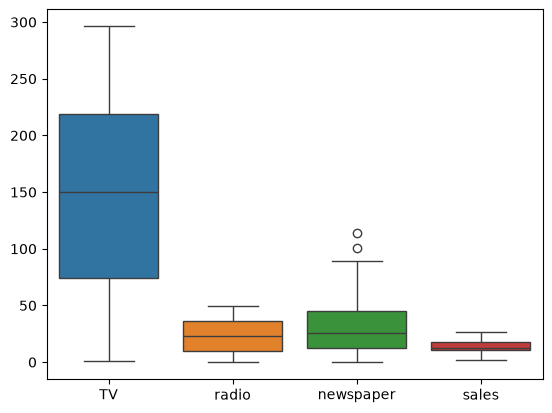

In [45]:
sns.boxplot(data=df)
plt.show()

In [46]:
df.tail()

,TV,radio,newspaper,sales
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5
199,232.1,8.6,8.7,13.4


In [47]:
Q1 = df['newspaper'].quantile(0.25)
Q3 = df['newspaper'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[(df['newspaper'] >= lower) &
              (df['newspaper'] <= upper)]

In [48]:
print(df.shape)
print(df_clean.shape)

(200, 4)
(198, 4)


In [49]:
df=df_clean
df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [9]:
df.sample(5)

,TV,radio,newspaper,sales
25,262.9,3.5,19.5,12.0
10,66.1,5.8,24.2,8.6
108,13.1,0.4,25.6,5.3
184,253.8,21.3,30.0,17.6
68,237.4,27.5,11.0,18.9


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 198 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         198 non-null    float64
 1   radio      198 non-null    float64
 2   newspaper  198 non-null    float64
 3   sales      198 non-null    float64
dtypes: float64(4)
memory usage: 7.7 KB


In [11]:
df.shape

(198, 4)

In [12]:
df.dtypes

TV           float64
radio        float64
newspaper    float64
sales        float64
dtype: object

In [13]:
df.columns

Index(['TV', 'radio', 'newspaper', 'sales'], dtype='object')

In [14]:
df.describe()

,TV,radio,newspaper,sales
count,198.000000,198.000000,198.000000,198.000000
mean,146.688384,23.130808,29.777273,13.980808
std,85.443221,14.862111,20.446303,5.196097
min,0.700000,0.000000,0.300000,1.600000
25%,74.800000,9.925000,12.650000,10.325000
50%,149.750000,22.400000,25.600000,12.900000
75%,218.475000,36.325000,44.050000,17.375000
max,293.600000,49.600000,89.400000,27.000000


In [15]:
df['Total_spend']=(df['TV']+df['radio']+df['newspaper'])

C:\Users\USER\AppData\Local\Temp\ipykernel_22460\2711429088.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Total_spend']=(df['TV']+df['radio']+df['newspaper'])


In [16]:
df

,TV,radio,newspaper,sales,Total_spend
0,230.1,37.8,69.2,22.1,337.1
1,44.5,39.3,45.1,10.4,128.9
2,17.2,45.9,69.3,9.3,132.4
3,151.5,41.3,58.5,18.5,251.3
4,180.8,10.8,58.4,12.9,250.0
...,...,...,...,...,...
195,38.2,3.7,13.8,7.6,55.7
196,94.2,4.9,8.1,9.7,107.2
197,177.0,9.3,6.4,12.8,192.7
198,283.6,42.0,66.2,25.5,391.8


In [17]:
df=df.drop(columns=['TV','radio','newspaper'])
df.head()

,sales,Total_spend
0,22.1,337.1
1,10.4,128.9
2,9.3,132.4
3,18.5,251.3
4,12.9,250.0


In [18]:
continous=['Total_spend','sales']

In [19]:
df[continous].describe()

,Total_spend,sales
count,198.000000,198.000000
mean,199.596465,13.980808
std,91.955928,5.196097
min,11.700000,1.600000
25%,121.050000,10.325000
50%,204.900000,12.900000
75%,280.525000,17.375000
max,402.400000,27.000000


In [20]:
df[continous].skew()

Total_spend    0.010179
sales          0.407130
dtype: float64

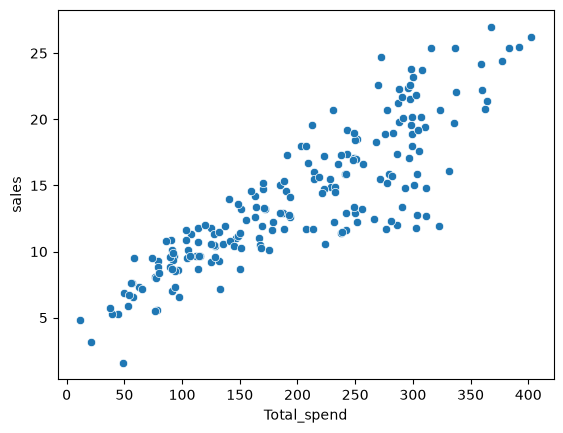

In [21]:
sns.scatterplot(x='Total_spend',y='sales',data=df)
plt.show()

In [22]:
df[continous].corr()

,Total_spend,sales
Total_spend,1.000000,0.865973
sales,0.865973,1.000000


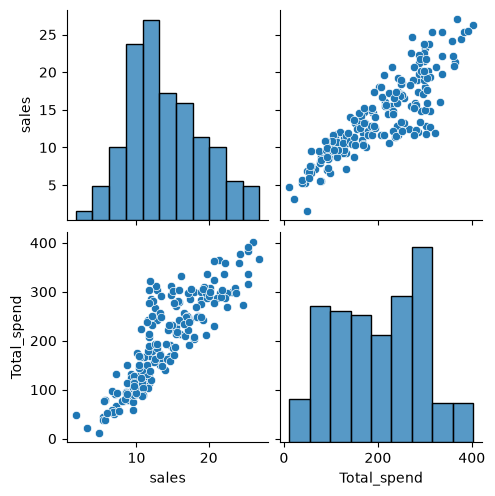

In [23]:
sns.pairplot(df)
plt.show()

In [24]:
df.isnull().sum()

sales          0
Total_spend    0
dtype: int64

In [25]:
X = df[['TV', 'radio', 'newspaper']]
y=df['sales']

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8,random_state=77)

In [27]:
from sklearn.linear_model import LinearRegression 
model =LinearRegression ()

# fit on data
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.05]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Total_spend']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.189
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [28]:
model.coef_

array([0.04904041])

In [29]:
model.intercept_

np.float64(4.188607924557958)

In [30]:
ypred_train=model.predict(X_train)
ypred_train

array([ 9.75959862,  8.70032574, 10.69136643,  9.7694067 , 12.97174554,
       20.03356473, 10.6766543 , 19.07727671, 12.17238684, 22.21586302,
        8.71503786, 12.19200301,  6.3807143 , 13.67792746, 18.42503925,
       22.0589337 , 18.20926144, 17.74828158, 12.40287677, 19.03314034,
       18.82226658,  8.78859848,  8.65618937, 18.06704425, 15.3649176 ,
       14.43805383,  9.31333088, 15.49242267, 16.51246322, 16.34082178,
       19.40094343,  8.07260848,  9.44573999, 12.51566972, 11.61332615,
       13.57003856, 15.42376609,  6.106088  , 19.47450404, 18.80755445,
        8.64638129,  8.57282067, 14.60479123, 10.92185636,  7.41056293,
       15.15404383, 12.01055348, 13.36897287, 11.08859376, 19.4450798 ,
       23.40264097, 16.76256931, 11.47110896,  6.03743142, 17.95915534,
       11.47110896, 16.44871068, 21.82844377, 18.02290788, 16.04167527,
       12.34893232, 20.01394856, 18.78793829, 16.05638739, 10.33827547,
       16.12013993, 18.30734226, 15.53655904, 11.2847554 , 14.70

In [39]:
from sklearn.metrics import mean_squared_error
# mean_squared_error(actual value predictd value )

print("Train RMSE:",np.sqrt(mean_squared_error(y_train,ypred_train)))
from sklearn.metrics import r2_score
print("Train R2:",r2_score(y_train,ypred_train))

Train RMSE: 2.6821097464214656
Train R2: 0.7349375428930318


In [32]:
ypred_test=model.predict(X_test)
ypred_test

array([ 9.81354307, 22.6670348 , 17.23335726,  7.28305786,  9.84787136,
       15.83570554, 18.30243822,  8.11184081, 11.54466958, 10.31375526,
        9.27900259, 16.74785719,  9.69584608,  9.48497232, 12.79029602,
       13.42291732, 16.42419048,  4.76238073, 11.53976554,  6.96919923,
       17.41480678,  9.25448238, 18.70456959, 13.40330116, 17.71885733,
       16.41928644, 18.84678678, 16.00244294, 12.43720506, 10.06364917,
       17.35105425,  8.8033106 ,  8.612053  , 14.3743013 ,  6.92015882,
       17.49817548, 17.90521089, 20.66618603,  5.23807272, 12.92270513])

In [40]:
from sklearn.metrics import mean_squared_error
# mean_squared_error(actual value predictd value )


print("Test RMSE:",np.sqrt(mean_squared_error(y_test,ypred_test)))
print("Test R2:",r2_score(y_test,ypred_test))

Test RMSE: 2.200106298048422
Test R2: 0.8045422289234475


In [41]:
from sklearn.model_selection import cross_val_score
print("CV score",cross_val_score(model,X_train,y_train,cv=5,scoring="neg_mean_squared_error").mean())

CV score -7.4130387650427725


In [35]:
print("CV score",cross_val_score(model,X_train,y_train,cv=5,scoring="r2").mean())
 

CV score 0.7172515177197313


**model id ready prediction sdtart**

In [36]:
model.predict([[20000]])

C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([984.99682857])

**save the model**

In [37]:
pwd

'D:\\data science classes\\regression'

In [38]:
from joblib import dump

#dump (model_name,name to save that model

dump(model,'sales_model.joblib')

['sales_model.joblib']

### How can you increase your model accuracy


In [50]:
df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [56]:
X = df[['TV', 'radio', 'newspaper']]
y = df['sales']

## Linear Regression performance - r2

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(r2_score(y_test, y_pred))
print("CV score",cross_val_score(model,X_train,y_train,cv=5,scoring="r2").mean())
 

0.9874697915921605
CV score 0.9771845715020502


## Use Polynomial Regression

In [58]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

model3 = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('linear', LinearRegression())
])

model3.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(r2_score(y_test, y_pred))
print("CV score",cross_val_score(model,X_train,y_train,cv=5,scoring="r2").mean())

0.9874697915921605
CV score 0.9771845715020502


In [64]:
df["Predicted_Sales"] = model.predict(df[['TV', 'radio', 'newspaper']])

print(df.head())

      TV  radio  newspaper  sales  Total  Predicted_Sales
0  230.1   37.8       69.2   22.1  337.1        21.659782
1   44.5   39.3       45.1   10.4  128.9        10.645797
2   17.2   45.9       69.3    9.3  132.4         8.907125
3  151.5   41.3       58.5   18.5  251.3        18.674277
4  180.8   10.8       58.4   12.9  250.0        13.244356


C:\Users\USER\AppData\Local\Temp\ipykernel_22460\1739027532.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Predicted_Sales"] = model.predict(df[['TV', 'radio', 'newspaper']])


In [65]:
total_predicted_sales = df["Predicted_Sales"].sum()
print("Total Predicted Sales:", total_predicted_sales)

Total Predicted Sales: 2772.0749857471656


In [66]:
print("Actual Total Sales:", df["sales"].sum())
print("Predicted Total Sales:", df["Predicted_Sales"].sum())

Actual Total Sales: 2768.2
Predicted Total Sales: 2772.0749857471656
